In [1]:
from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics
import numpy as np

from matplotlib import pyplot as plt

import pandas as pd

import torch
from torch.nn import functional as F
from tqdm import tqdm

from torch.utils.data import random_split

In [2]:
DEVICE = utils.get_device()

DEVICE

'cuda'

In [3]:
MODEL_NAME = "imagenet-resnet18-tv"
LAYER = "layer3"

DATASET_NAME = "imagenet-butterfly"

In [4]:
dataset = datasets.construct(DATASET_NAME)

In [5]:
trng = torch.Generator()
trng.manual_seed(1)

ds_train = dataset.create_subset(train_split=True)
training_size = 1.0
ds_train, _ = random_split(ds_train, [training_size, 1-training_size], generator=trng)
dl_train = datasets.build_dataloader(ds_train, shuffle=False)
ds_val = dataset.create_subset(train_split=False)
dl_val = datasets.build_dataloader(ds_val, shuffle=False)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|█████████████████████████████████████████████████████████████████████████| 7800/7800 [00:00<00:00, 3416769.84it/s]
/usr/local/lib/python3.11/site-packages/torch/utils/data/dataset.py:348: UserWarning: Length of split at index 1 is 0. This might result in an empty dataset.
  warnings.warn(f"Length of split at index {i} is 0. "


We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|███████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 1033928.68it/s]


In [6]:
model = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(
    model=model,
    selected_classes=dataset.selected_classes
)
model.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
class Top2WinningClassesEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        # find the label of two winning classes
        _, indices = torch.topk(logits, dim=1, k=2)
        return logits * F.one_hot(indices[:, 0], self.num_classes) + logits * F.one_hot(
            indices[:, 1], self.num_classes
        )

    def __str__(self) -> str:
        return "contrasttop2"

In [8]:
logit_mod = Top2WinningClassesEvidence(num_classes=dataset.num_classes)
logit_mod = attributors.DifferenceTop2WinningClassesEvidence(num_classes=dataset.num_classes)
rng = np.random.default_rng(seed=1)

In [9]:
def extract_act_ctx(logit_mod):
    
    return attributors.extract_activation_context(
        model=model,
        layer=LAYER,
        dataset=dataset,
        data_loader=dl_train,
        logit_modifier=logit_mod,
        rng=rng,
        device=DEVICE,
    )

In [10]:
logit_mod_winning = attributors.WinningClassEvidence(num_classes=dataset.num_classes)
logit_mod_top2diff = attributors.DifferenceTop2WinningClassesEvidence(num_classes=dataset.num_classes)
logit_mod_top2 = Top2WinningClassesEvidence(num_classes=dataset.num_classes)
logit_mod_allclasses = attributors.ALlClassesEvidence(num_classes=dataset.num_classes)
logit_mod_target = attributors.TargetClassEvidence(num_classes=dataset.num_classes)

In [11]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs


def estimate_basis(name):
    if name == "pca":
        arr_act, _ = extract_act_ctx(logit_mod_winning)
        return _solve_eigvecs(arr_act.T @ arr_act)
    elif name == "prca-winning":
        arr_act, arr_ctx = extract_act_ctx(logit_mod_winning)

        return _solve_eigvecs(
            arr_act.T @ arr_ctx + arr_ctx.T @ arr_act ,
            sort_func=np.abs
        )
    elif name == "prca-top2":
        arr_act, arr_ctx = extract_act_ctx(logit_mod_top2)

        return _solve_eigvecs(
            arr_act.T @ arr_ctx + arr_ctx.T @ arr_act ,
            sort_func=np.abs
        )
    elif name == "prca-target":
        arr_act, arr_ctx = extract_act_ctx(logit_mod_target)

        return _solve_eigvecs(
            arr_act.T @ arr_ctx + arr_ctx.T @ arr_act ,
            sort_func=np.abs
        )
        
    else:
        raise

In [12]:
def ano():
    for basis_name in ["pca", "prca-winning", "prca-top2"]:
        U = estimate_basis(basis_name)
        assert U is not None
    print("sanity check: passed!")
# ano()

In [13]:
def construct_fh(UUk):

    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            UUk
        ) 

    return fh

def estimate_acc_at_k(basis_name, arr_ks):


    U = estimate_basis(basis_name)
    
    arr_rows = []

    for k in tqdm(arr_ks):
        Uk = U[:, :k]
        UUk = torch.from_numpy(Uk @ Uk.T).unsqueeze(2).unsqueeze(3).to(DEVICE)
        
        try:
            hook = getattr(model, LAYER).register_forward_hook(construct_fh(UUk))
            acc, xent = metrics.accuracy(
                model=model,
                dataloader=dl_val,
                num_classes=len(dataset.selected_classes),
                device=DEVICE
            )
            arr_rows.append(dict(
                basis_name=basis_name, 
                k=k,
                val_acc=acc,
                val_loss=xent
            ))
        finally:
            hook.remove()


    return pd.DataFrame(arr_rows)

estimate_acc_at_k("prca-winning", np.arange(0, 10, 2).tolist() + [256])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 122/122 [01:19<00:00,  1.54it/s]


layer3: output-dims=torch.Size([256, 14, 14])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:13<00:00,  2.20s/it]


,basis_name,k,val_acc,val_loss
0,prca-winning,0,0.166667,2.247296
1,prca-winning,2,0.166667,1.834773
2,prca-winning,4,0.330000,1.591617
3,prca-winning,6,0.553333,1.350438
4,prca-winning,8,0.710000,1.101239
5,prca-winning,256,0.966667,0.174801


[32, 54, 77, 100, 123, 146, 169, 192, 256]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 122/122 [00:42<00:00,  2.88it/s]


layer3: output-dims=torch.Size([256, 14, 14])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 122/122 [00:42<00:00,  2.90it/s]


layer3: output-dims=torch.Size([256, 14, 14])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 122/122 [00:42<00:00,  2.87it/s]


layer3: output-dims=torch.Size([256, 14, 14])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:20<00:00,  2.26s/it]


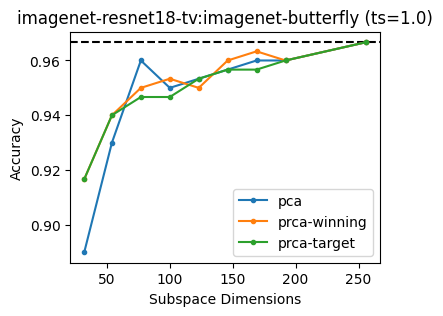

In [24]:
def viz():
    d = 256
    # arr_act.shape[1]

    plt.figure(figsize=(4, 3))
    plt.title(f"{MODEL_NAME}:{DATASET_NAME} (ts={training_size})")
    
    arr_ks =  np.linspace(d//8, int(3*d//4), num=8).astype(int).tolist() + [d]
    print(arr_ks)
    
    for bix, basis_name in enumerate([
        "pca", 
        "prca-winning", 
        "prca-target",
    ]):
        df = estimate_acc_at_k(basis_name, arr_ks)

        if bix == 0:
            plt.axhline(df["val_acc"].values[-1], ls="--", color="k")

        # if "unit" in basis_name:
        #     ls = ":"
        #     color= plt.gca().lines[-1].get_color()
        # else:
        #     ls = "-"
        #     color = None
        plt.plot(
            df.k,
            df.val_acc,
            label=basis_name,
            # color=color,
            # ls=ls,
            marker="."
        )
    plt.xlabel("Subspace Dimensions")
    plt.ylabel("Accuracy")
    plt.legend()
viz()

In [21]:
def ano():
    d = 256
    print(d * 3/ 4)
    return np.linspace(d//4, int(3*d//2), num=8).astype(int).tolist() + [256]
ano()

192.0


[64, 109, 155, 201, 246, 292, 338, 384, 256]